# NB2: Phenotype Associations & Functional Enrichment (Pan-GWAS)

**FunPan Aspergillus Pangenome Project** -- Results 3.2 + 3.5

This notebook performs:
1. One-vs-rest phenotype construction for each species
2. LMM-based association testing (EMMA-style) across PAV, CNV, BGC, GCF, and functional count matrices
3. Power analysis for imbalanced designs (e.g. A. oryzae 31:1)
4. Functional enrichment of significant hits (COG, Pfam, CAZy, KEGG, GO, InterPro)
5. BGC co-localisation of significant orthogroups

**Inputs:** NB0_Results (phenotype tables), NB1_Results (PAV/CNV/kinship/PCs/BGC/GCF matrices, OG consensus tables)  
**Outputs:** NB2_Results/

---
## Section 1: Configuration & Data Loading

In [2]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Add Code directory to path
sys.path.insert(0, '/datadrive/Analysis')
import funpan_utils as utils
import funpan_gwas as gwas

print('Modules loaded successfully.')

Modules loaded successfully.


In [3]:
# --- Paths ---
BASE_DIR = Path('/datadrive')
ANALYSIS_DIR = BASE_DIR / 'Analysis'
NB0_RESULTS = ANALYSIS_DIR / 'NB0_Results'
NB1_RESULTS = ANALYSIS_DIR / 'NB1_Results'
NB2_RESULTS = ANALYSIS_DIR / 'NB2_Results'

NB2_RESULTS.mkdir(parents=True, exist_ok=True)

# Species list
SPECIES = utils.SPECIES_LIST  # e.g. ['A_fumigatus', 'A_flavus', 'A_niger', 'A_oryzae']
print(f'Species: {SPECIES}')

# Feature layers to test
FEATURE_LAYERS = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']

# Annotation layers for enrichment
ANNOTATION_LAYERS = ['COG_category', 'PFAMs', 'CAZy', 'KEGG_ko', 'KEGG_Pathway', 'KEGG_TC', 'GOs', 'interpro_IPR', 'EC', 'dbcan_Substrate']

# FDR threshold
FDR_THRESHOLD = 0.05

Species: ['fumigatus', 'flavus', 'niger', 'oryzae']


In [4]:
# --- Load phenotype classification table ---
pheno_classified = pd.read_csv(NB0_RESULTS / 'phenotype_classified_for_gwas.csv', index_col=0)
print(f'Phenotype classification table: {pheno_classified.shape}')
display(pheno_classified.head())

Phenotype classification table: (207, 68)


,Assembly Name,Organism Name,Organism Taxonomic ID,ANI Check status,Organism Infraspecific Names Breed,Organism Infraspecific Names Strain,Organism Infraspecific Names Cultivar,Organism Infraspecific Names Ecotype,Organism Infraspecific Names Isolate,Organism Infraspecific Names Sex,...,PhenotypeScores,PhenotypeMatched,FieldProvenance,NegationsApplied,IsolationClass,IsolationSubclass,IsolationSubtype,ClassConfidence,ClassificationConfidence,UsageClass
Assembly Accession,,,,,,,,,,,,,,,,,,,,,
GCA_000150145.1,ASM15014v1,Aspergillus fumigatus A1163,451804,NaN,NaN,A1163,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 10.0, ""Animal-pathogenic""...","{""Human-pathogenic"": [""Established strain: Asp...","{""Provenance:Clinical"": [""description"", ""comme...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
GCA_001599455.1,JCM_10253_assembly_v001,Aspergillus fumigatus var. fumigatus,41122,NaN,NaN,JCM 10253,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""description"", ""...",[],Environmental,Environmental,Environmental,low,low,Wild-type
GCA_001715275.2,ASM171527v2,Aspergillus fumigatus,746128,NaN,NaN,LMB-35Aa,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 0.0, ""Animal-pathogenic"":...","{""Environmental"": [""Inferred from Environmenta...","{""Provenance:Environmental"": [""isolation_sourc...",[],Environmental,Environmental,Environmental,low,low,Wild-type
GCA_015572005.1,ASM1557200v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA A,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic
GCA_015572015.1,ASM1557201v1,Aspergillus fumigatus,746128,NaN,NaN,CAPA B,NaN,NaN,NaN,NaN,...,"{""Human-pathogenic"": 9.0, ""Animal-pathogenic"":...","{""Human-pathogenic"": [""aspergillosis"", ""CAPA"",...","{""Provenance:Clinical"": [""isolation_source"", ""...",[],Human,Human-pathogenic,Human-pathogenic,high,high,Pathogenic


In [5]:
# --- Load per-species data: PAV, CNV, kinship, PCs, BGC/GCF matrices ---
species_data = gwas.load_all_species_gwas_data(
    SPECIES, NB0_RESULTS, NB1_RESULTS, ANNOTATION_LAYERS
)

fumigatus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
flavus: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
niger: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']
oryzae: loaded 9 data objects -- ['phenotype', 'pav', 'cnv', 'kinship', 'pcs', 'bgc_pav', 'gcf_pav', 'gcf_cnv', 'og_consensus']


---
## Section 2: One-vs-Rest Phenotype Construction

For each species, create binary one-vs-rest contrasts (e.g. `human_pathogenic_vs_rest`, `industrial_trait_vs_rest`).  
These encode which isolates belong to a phenotypic category versus all others.

In [6]:
# Build one-vs-rest phenotype contrasts per species
species_contrasts = gwas.build_all_phenotype_contrasts(
    SPECIES, species_data, NB2_RESULTS
)

fumigatus: loaded 2 cached contrasts
flavus: loaded 3 cached contrasts
niger: loaded 2 cached contrasts

oryzae -- 0 contrasts:


---
## Section 3: LMM Association Testing (Per Species)

For each species x contrast x feature layer, run EMMA-style linear mixed model association tests:
- Fit null LMM with kinship + SNP PCs as covariates
- Test each feature (orthogroup / BGC / GCF / functional term) for association
- Apply Benjamini-Hochberg FDR correction
- Generate diagnostic plots (QQ, inflation factor, p-value histogram)

In [7]:
# Run association testing for all species x contrast x feature layer combinations
all_results = gwas.run_all_associations(
    SPECIES, species_contrasts, species_data, NB2_RESULTS,
    FEATURE_LAYERS, ANNOTATION_LAYERS, FDR_THRESHOLD
)


fumigatus: running association tests

  Contrast: human_pathogenic_vs_rest
    Layer: pav (89 features) ... cached (93 significant)
    Layer: cnv (89 features) ... cached (87 significant)
    Layer: bgc_pav (89 features) ... cached (0 significant)
    Layer: gcf_pav (89 features) ... cached (3 significant)
    Layer: gcf_cnv (89 features) ... cached (3 significant)

  Contrast: environmental_vs_rest
    Layer: pav (89 features) ... cached (93 significant)
    Layer: cnv (89 features) ... cached (87 significant)
    Layer: bgc_pav (89 features) ... cached (0 significant)
    Layer: gcf_pav (89 features) ... cached (3 significant)
    Layer: gcf_cnv (89 features) ... cached (3 significant)

flavus: running association tests

  Contrast: plant_pathogenic_vs_rest
    Layer: pav (70 features) ... cached (117 significant)
    Layer: cnv (70 features) ... cached (98 significant)
    Layer: bgc_pav (70 features) ... cached (0 significant)
    Layer: gcf_pav (70 features) ... cached (4 signif

In [8]:
# --- Diagnostic plots for each association test ---
for (sp, contrast_name, layer_name), results in all_results.items():
    if 'pvalue' not in results.columns or results['pvalue'].dropna().empty:
        continue
    
    sp_results_dir = NB2_RESULTS / sp / 'pangwas_results'
    diag_path = sp_results_dir / f'{layer_name}_{contrast_name}_diagnostics.png'
    
    pvals = results['pvalue'].dropna().values
    
    # Calculate genomic inflation factor
    lambda_gc = gwas.calculate_genomic_inflation(pvals)
    
    # Create diagnostic plots
    fig = gwas.create_diagnostic_plots(pvals, title=f'{sp} | {layer_name} | {contrast_name}')
    fig.savefig(diag_path, dpi=150, bbox_inches='tight')
    plt.close(fig)

print('Diagnostic plots saved.')

Diagnostic plots saved.


In [9]:
# --- Summary table of significant hits across species x contrast x layer ---
summary_rows = []
for (sp, contrast, layer), res in all_results.items():
    n_tested = len(res)
    n_sig = int(res.get('significant', pd.Series(dtype=bool)).sum()) if 'significant' in res.columns else 0
    lambda_gc = gwas.calculate_genomic_inflation(res['pvalue'].dropna().values) if 'pvalue' in res.columns and len(res['pvalue'].dropna()) > 0 else np.nan
    summary_rows.append({
        'species': sp,
        'contrast': contrast,
        'feature_layer': layer,
        'n_tested': n_tested,
        'n_significant': n_sig,
        'lambda_gc': round(lambda_gc, 3) if not np.isnan(lambda_gc) else np.nan
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df.sort_values(['species', 'contrast', 'feature_layer']))

,species,contrast,feature_layer,n_tested,n_significant,lambda_gc
17,flavus,environmental_vs_rest,bgc_pav,0,0,NaN
16,flavus,environmental_vs_rest,cnv,3011,27,0.003
19,flavus,environmental_vs_rest,gcf_cnv,85,0,0.004
18,flavus,environmental_vs_rest,gcf_pav,85,0,0.004
15,flavus,environmental_vs_rest,pav,3011,28,0.004
22,flavus,human_pathogenic_vs_rest,bgc_pav,0,0,NaN
21,flavus,human_pathogenic_vs_rest,cnv,3011,49,0.027
24,flavus,human_pathogenic_vs_rest,gcf_cnv,85,1,0.054
23,flavus,human_pathogenic_vs_rest,gcf_pav,85,1,0.054
20,flavus,human_pathogenic_vs_rest,pav,3011,62,0.047


In [10]:
# --- Interpretation: Pan-GWAS Results Summary ---
print('Pan-GWAS Results Summary')
print('=' * 60)
for (sp, contrast, layer), res in sorted(all_results.items()):
    if 'pvalue' not in res.columns:
        continue
    n_tested = len(res)
    n_sig = (res.get('qvalue', res.get('fdr', pd.Series())) < 0.05).sum()
    if n_sig > 0 or layer == 'PAV':
        print(f'  A. {sp} | {contrast} | {layer}: {n_sig}/{n_tested} significant (FDR < 0.05)')


Pan-GWAS Results Summary
  A. flavus | environmental_vs_rest | cnv: 27/3011 significant (FDR < 0.05)
  A. flavus | environmental_vs_rest | pav: 28/3011 significant (FDR < 0.05)
  A. flavus | human_pathogenic_vs_rest | cnv: 49/3011 significant (FDR < 0.05)
  A. flavus | human_pathogenic_vs_rest | gcf_cnv: 1/85 significant (FDR < 0.05)
  A. flavus | human_pathogenic_vs_rest | gcf_pav: 1/85 significant (FDR < 0.05)
  A. flavus | human_pathogenic_vs_rest | pav: 62/3011 significant (FDR < 0.05)
  A. flavus | plant_pathogenic_vs_rest | cnv: 98/3011 significant (FDR < 0.05)
  A. flavus | plant_pathogenic_vs_rest | gcf_cnv: 4/85 significant (FDR < 0.05)
  A. flavus | plant_pathogenic_vs_rest | gcf_pav: 4/85 significant (FDR < 0.05)
  A. flavus | plant_pathogenic_vs_rest | pav: 117/3011 significant (FDR < 0.05)
  A. fumigatus | environmental_vs_rest | cnv: 87/1876 significant (FDR < 0.05)
  A. fumigatus | environmental_vs_rest | gcf_cnv: 3/34 significant (FDR < 0.05)
  A. fumigatus | environmen

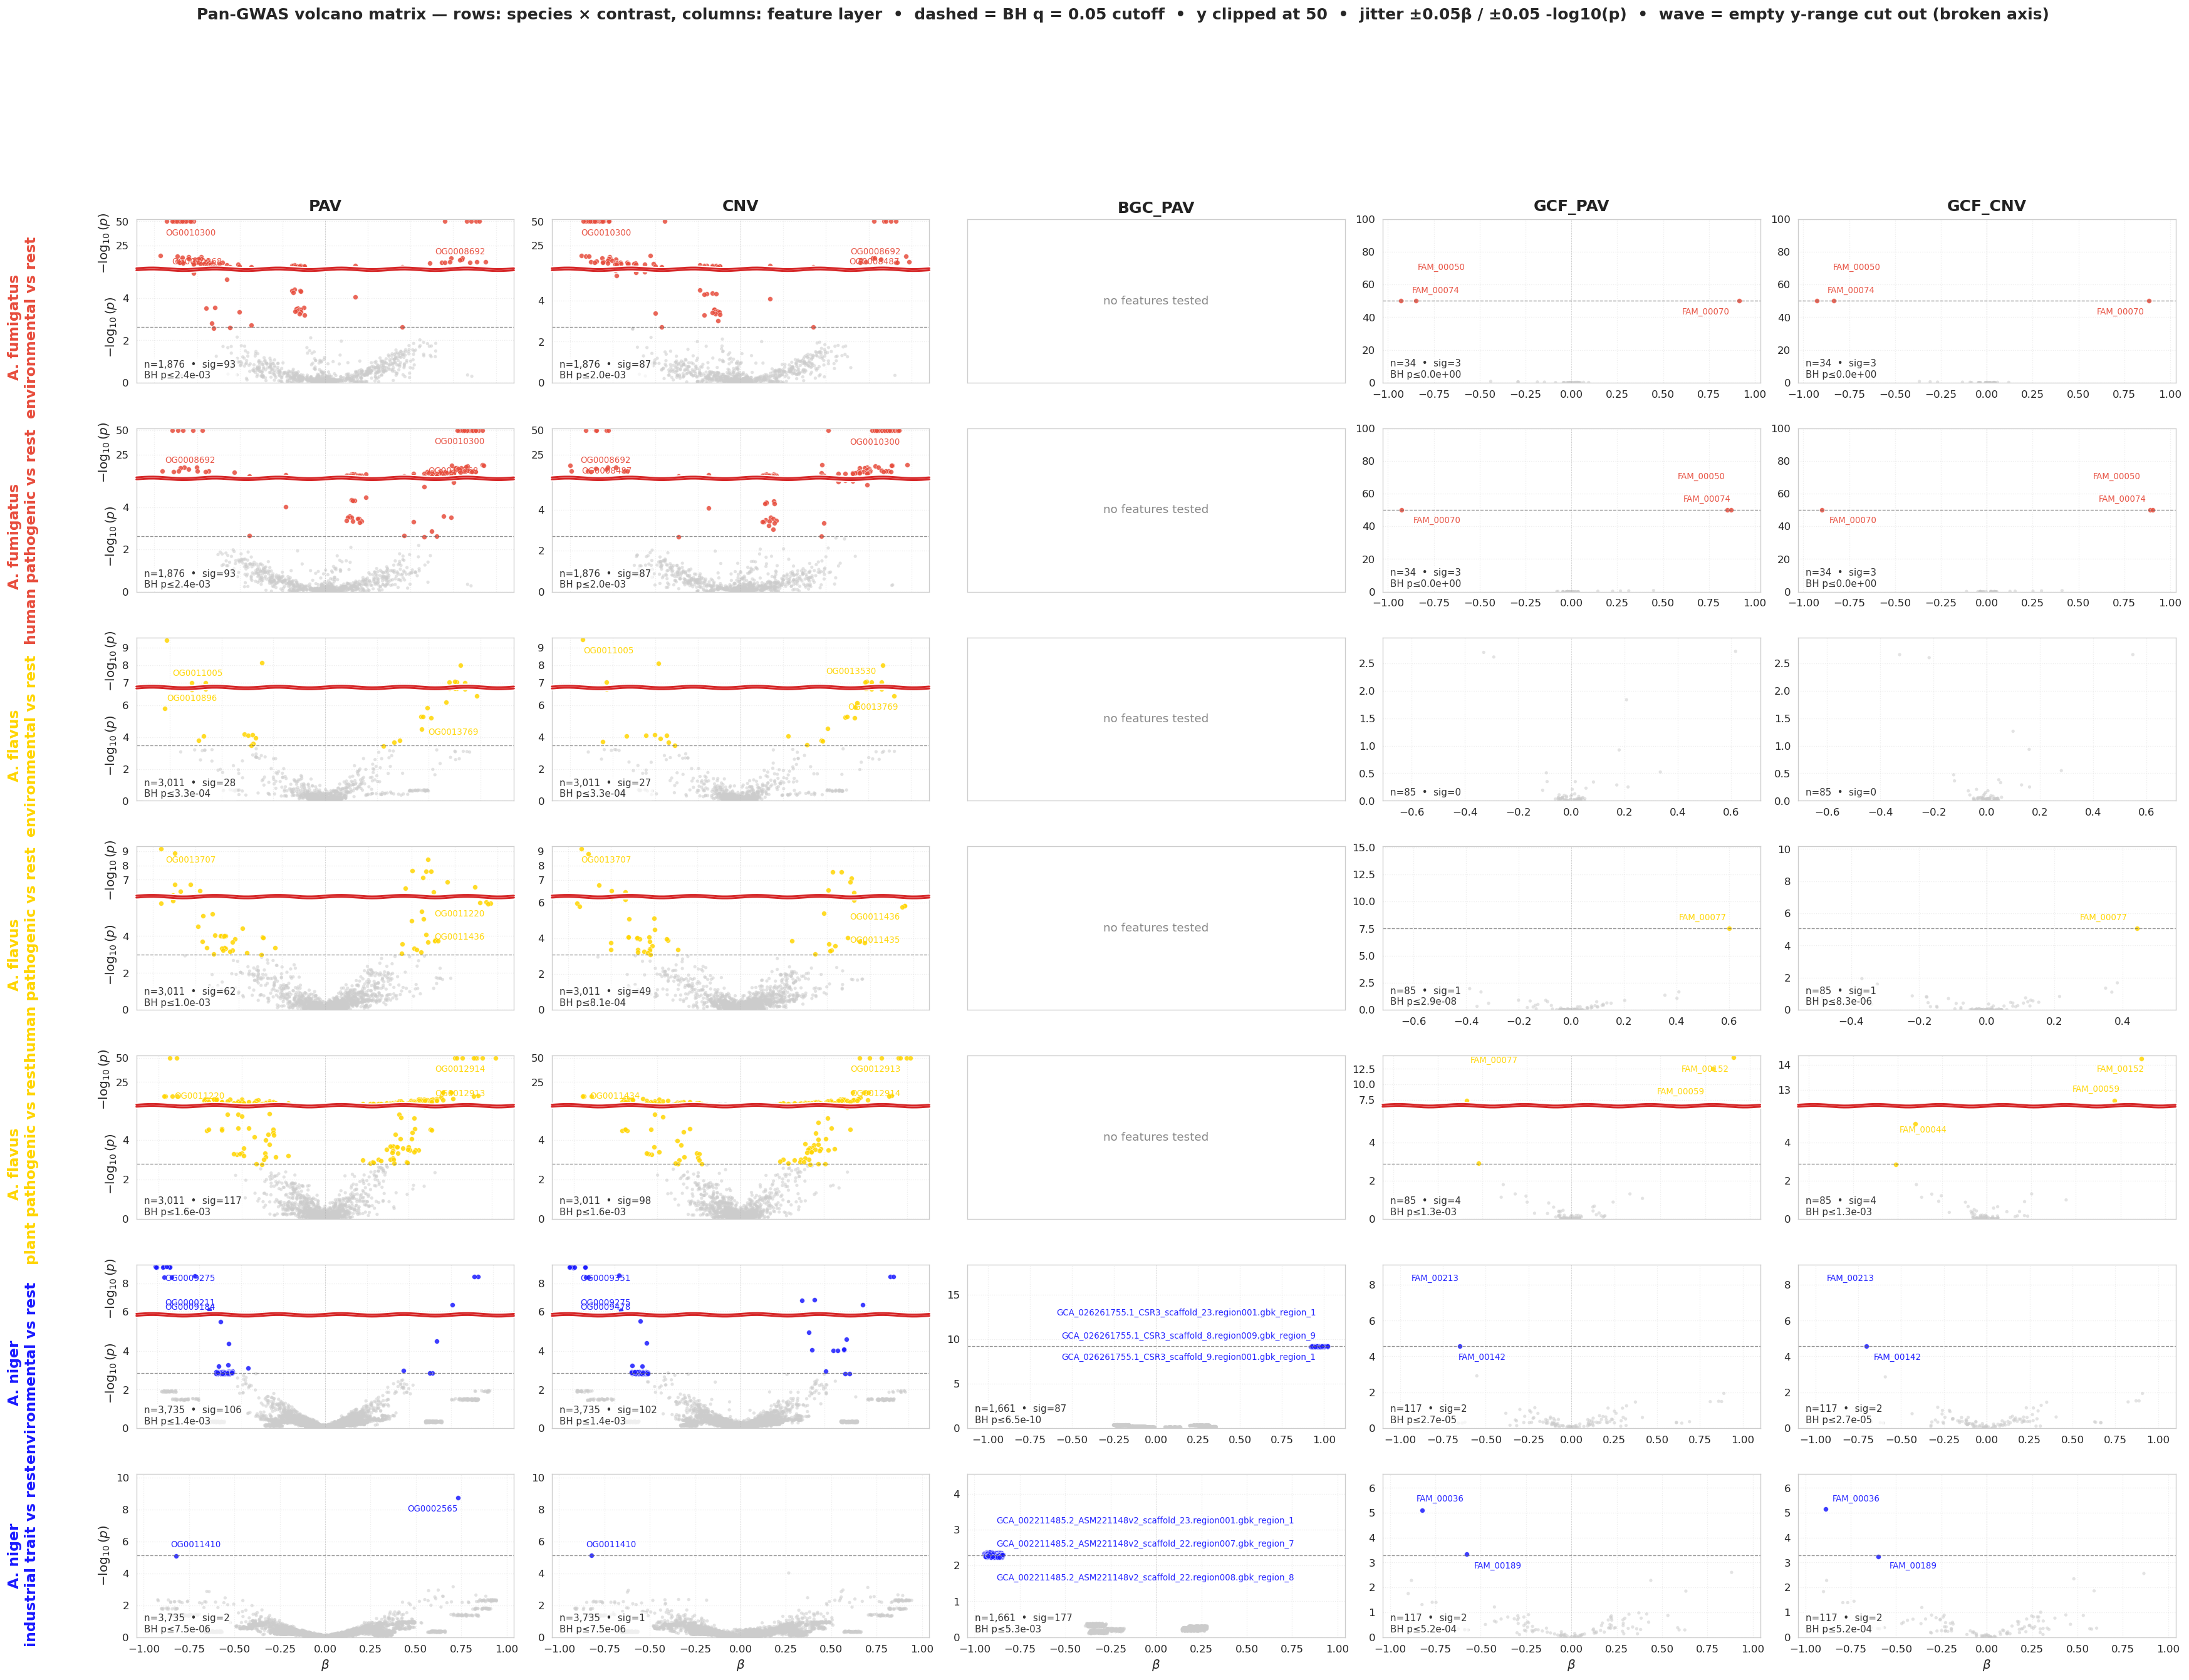

Saved -> /datadrive/Analysis/NB2_Results/volcano_grid_all_layers.png  (+ .pdf)
Rows (species × contrast): 7   Columns (layers): 5


In [11]:
# --- Volcano plot matrix: rows = (species, contrast), cols = feature layer ---
# Y-axis = -log10(p). Dashed line per panel = the largest p that still passes
# BH-FDR at Q_THRESHOLD.
# - X-axis symmetric around β = 0.
# - In the (single-axis) panels the BH cutoff line sits at the center of y.
# - When a few sig points sit far above the centered y-range, the panel uses
#   a PROPER BROKEN Y-AXIS: a lower sub-axis (cutoff centered) and a smaller
#   upper sub-axis covering the overflow region. Both sub-axes carry
#   accurate -log10(p) tick labels; the wave between them denotes the empty
#   y-range that was cut out.
# - JITTER spreads stacked points (visual only).
# --- Tweakable parameters ---
FS               = 13
DPI              = 400
FIG_W_PER_LAYER  = 7.0
FIG_H_PER_ROW    = 3.5
N_TOP_LABELS     = 3
Q_THRESHOLD      = 0.05
Y_MAX_CLIP       = 50
LAYERS           = ['pav', 'cnv', 'bgc_pav', 'gcf_pav', 'gcf_cnv']
# Jitter
JITTER_X         = 0.05
JITTER_Y         = 0.05
JITTER_SEED      = 0
# Y-axis layout
Y_MIN_HALF_RANGE   = 1.0
GAP_TRIGGER_FACTOR = 1.25
UPPER_HEIGHT_RATIO = 0.30
OVERFLOW_PADDING   = 0.05


import matplotlib.gridspec as gridspec


def _safe_load_assoc(path):
    if not path.exists() or path.stat().st_size < 10:
        return None, 'empty' if path.exists() else 'missing'
    try:
        df = pd.read_csv(path, sep='\t')
    except Exception:
        return None, 'empty'
    if df.empty or 'beta' not in df.columns or 'pvalue' not in df.columns:
        return None, 'empty'
    df = df.dropna(subset=['beta', 'pvalue']).copy()
    if df.empty:
        return None, 'empty'
    return df, 'ok'


def _draw_wave(ax, fraction=0.0, n=200, color='#d62728', lw=1.4):
    """Sinusoidal wave at axes-coord y=fraction.
    Peaks always point INTO the broken-axis gap so the two cuts mirror each other.
    """
    import numpy as _np
    xs = _np.linspace(0.0, 1.0, n)
    sign = 1.0 if fraction >= 0.5 else -1.0
    ys = fraction + sign * 0.014 * _np.sin(10 * _np.pi * xs)
    ax.plot(xs, ys, transform=ax.transAxes, color='white',
            linewidth=lw + 2.8, solid_capstyle='round',
            clip_on=False, zorder=10)
    ax.plot(xs, ys, transform=ax.transAxes, color=color,
            linewidth=lw, solid_capstyle='round',
            clip_on=False, zorder=11)


row_keys = []
for sp in SPECIES:
    sp_dir = NB2_RESULTS / sp / 'pangwas_results'
    if not sp_dir.exists():
        continue
    contrasts_seen = set()
    for layer in LAYERS:
        for f in sorted(sp_dir.glob(f'{layer}_assoc_*.tsv')):
            c = f.stem.replace(f'{layer}_assoc_', '')
            contrasts_seen.add(c)
    for c in sorted(contrasts_seen):
        row_keys.append((sp, c))

if not row_keys:
    print('No association TSVs found under NB2_Results/.')
else:
    nrows, ncols = len(row_keys), len(LAYERS)
    fig = plt.figure(figsize=(FIG_W_PER_LAYER * ncols,
                              FIG_H_PER_ROW * nrows))
    outer_gs = gridspec.GridSpec(nrows, ncols, figure=fig,
                                  hspace=0.28, wspace=0.10)
    SP_COLORS = utils.SPECIES_COLORS
    rng_master = np.random.default_rng(JITTER_SEED)

    for ri, (sp, contrast) in enumerate(row_keys):
        color = SP_COLORS.get(sp, '#444444')
        for ci, layer in enumerate(LAYERS):
            spec = outer_gs[ri, ci]
            path = NB2_RESULTS / sp / 'pangwas_results' / f'{layer}_assoc_{contrast}.tsv'
            df, status = _safe_load_assoc(path)

            if status != 'ok':
                ax = fig.add_subplot(spec)
                msg = 'no TSV' if status == 'missing' else 'no features tested'
                ax.text(0.5, 0.5, msg, transform=ax.transAxes,
                        ha='center', va='center', fontsize=FS - 2, color='#888')
                ax.set_xticks([]); ax.set_yticks([])
                if ri == 0:
                    ax.set_title(layer.upper(), fontsize=FS + 2,
                                 fontweight='bold', color='#222')
                if ci == 0:
                    ax.text(-0.30, 0.5,
                            f"A. {sp}\n{contrast.replace('_', ' ')}",
                            transform=ax.transAxes,
                            rotation=90, ha='center', va='center',
                            fontsize=FS + 1, fontweight='bold', color=color)
                continue

            df['pvalue_clip'] = df['pvalue'].clip(lower=1e-300)
            df['neglog10p']   = -np.log10(df['pvalue_clip'])
            if Y_MAX_CLIP is not None:
                df['neglog10p'] = df['neglog10p'].clip(upper=Y_MAX_CLIP)
            if 'significant' in df.columns:
                sig_mask = df['significant'].astype(bool)
            elif 'qvalue' in df.columns:
                sig_mask = df['qvalue'].fillna(1.0) < Q_THRESHOLD
            else:
                sig_mask = pd.Series(False, index=df.index)

            if sig_mask.any():
                p_cutoff = float(df.loc[sig_mask, 'pvalue'].max())
                cutoff_y = -np.log10(max(p_cutoff, 1e-300))
                if Y_MAX_CLIP is not None:
                    cutoff_y = min(cutoff_y, Y_MAX_CLIP)
            else:
                p_cutoff = None; cutoff_y = None

            y_data_max = float(df['neglog10p'].max())

            broken = False
            upper_lo = upper_hi = None
            if cutoff_y is not None:
                half = max(cutoff_y, Y_MIN_HALF_RANGE)
                ylim_lo = max(0.0, cutoff_y - half)
                lower_top = cutoff_y + half
                if y_data_max > lower_top * GAP_TRIGGER_FACTOR:
                    broken = True
                    overflow_vals = df.loc[df['neglog10p'] > lower_top, 'neglog10p']
                    upper_lo = float(overflow_vals.min())
                    upper_hi = float(overflow_vals.max())
                    span = max(upper_hi - upper_lo, 1.0)
                    upper_lo -= span * OVERFLOW_PADDING
                    upper_hi += span * OVERFLOW_PADDING
            else:
                ylim_lo = 0.0
                lower_top = max(y_data_max * 1.10, Y_MIN_HALF_RANGE * 2)

            if broken:
                inner = gridspec.GridSpecFromSubplotSpec(
                    2, 1, subplot_spec=spec,
                    height_ratios=[UPPER_HEIGHT_RATIO, 1.0 - UPPER_HEIGHT_RATIO],
                    hspace=0.07)
                ax_lower = fig.add_subplot(inner[1])
                ax_upper = fig.add_subplot(inner[0], sharex=ax_lower)
            else:
                ax_lower = fig.add_subplot(spec)
                ax_upper = None

            if ri == 0:
                top_ax = ax_upper if ax_upper is not None else ax_lower
                top_ax.set_title(layer.upper(), fontsize=FS + 2,
                                 fontweight='bold', color='#222', pad=8)
            if ci == 0:
                ax_lower.text(-0.30, 0.5,
                              f"A. {sp}\n{contrast.replace('_', ' ')}",
                              transform=ax_lower.transAxes,
                              rotation=90, ha='center', va='center',
                              fontsize=FS + 1, fontweight='bold', color=color)

            n = len(df)
            jx = rng_master.uniform(-JITTER_X, JITTER_X, size=n) if JITTER_X else np.zeros(n)
            jy = rng_master.uniform(-JITTER_Y, JITTER_Y, size=n) if JITTER_Y else np.zeros(n)
            beta_plot = df['beta'].values + jx
            nlp_plot  = df['neglog10p'].values + jy

            for axx in ([ax_lower] if not broken else [ax_lower, ax_upper]):
                axx.scatter(beta_plot[~sig_mask.values], nlp_plot[~sig_mask.values],
                            s=10, color='#cccccc', alpha=0.55, edgecolor='none')
                axx.scatter(beta_plot[sig_mask.values], nlp_plot[sig_mask.values],
                            s=22, color=color, alpha=0.85,
                            edgecolor='white', linewidth=0.3)
                if cutoff_y is not None:
                    axx.axhline(cutoff_y, color='#666', linestyle='--',
                                linewidth=0.8, alpha=0.7)
                axx.axvline(0, color='#aaa', linestyle=':',
                            linewidth=0.6, alpha=0.6)
                axx.grid(True, linestyle=':', alpha=0.35)
                axx.tick_params(axis='both', labelsize=FS - 3)

            x_max_abs = float(np.nanmax(np.abs(df['beta'].values)))
            x_max_abs = max(x_max_abs + abs(JITTER_X), 0.5)
            xlim = (-x_max_abs * 1.10, x_max_abs * 1.10)
            ax_lower.set_xlim(xlim)
            ax_lower.set_ylim(ylim_lo, lower_top)
            if ax_upper is not None:
                ax_upper.set_xlim(xlim)
                ax_upper.set_ylim(upper_lo, upper_hi)
                ax_lower.spines['top'].set_visible(False)
                ax_upper.spines['bottom'].set_visible(False)
                ax_upper.tick_params(labeltop=False, top=False, bottom=False)
                ax_upper.set_xticklabels([])

                # Draw TWO PARALLEL waves in figure coords across the gap.
                # Both waves use the same +sin phase (same direction) so peaks
                # of one align with peaks of the other -- they're parallel.
                # The vertical offset keeps them visibly separated.
                import matplotlib.lines as _mlines
                bbox_up = ax_upper.get_position()
                bbox_lo = ax_lower.get_position()
                gap_lo = bbox_lo.y1
                gap_hi = bbox_up.y0
                gap_y  = (gap_lo + gap_hi) / 2.0
                gap_h  = max(gap_hi - gap_lo, 1e-6)
                x_left  = max(bbox_up.x0, bbox_lo.x0)
                x_right = min(bbox_up.x1, bbox_lo.x1)
                _xs   = np.linspace(x_left, x_right, 240)
                _phase = np.sin(12 * np.pi * (_xs - x_left) / (x_right - x_left))
                _off  = gap_h * 0.18           # separation between the two parallel waves
                _amp  = gap_h * 0.14           # shared amplitude
                _y_top = (gap_y + _off) + _amp * _phase           # upper wave
                _y_bot = (gap_y - _off) + _amp * _phase           # lower wave, SAME phase = parallel
                for _ys in (_y_top, _y_bot):
                    fig.add_artist(_mlines.Line2D(_xs, _ys, color='white',
                                                  linewidth=4.0, solid_capstyle='round',
                                                  zorder=10, transform=fig.transFigure))
                    fig.add_artist(_mlines.Line2D(_xs, _ys, color='#d62728',
                                                  linewidth=1.8, solid_capstyle='round',
                                                  zorder=11, transform=fig.transFigure))

            if sig_mask.any() and N_TOP_LABELS > 0:
                top = (df[sig_mask]
                       .assign(absbeta=df.loc[sig_mask, 'beta'].abs())
                       .sort_values('absbeta', ascending=False)
                       .head(N_TOP_LABELS))
                STEP_PTS = 22         # initial stagger between pairs (pts)
                MIN_SEP_PTS = 12      # min vertical separation between any two labels (pts)
                _placed_y_fig = []    # fig-y positions of labels placed in THIS panel
                _ppx = fig.dpi / 72.0
                _fh = fig.get_figheight()
                _min_sep_figy = MIN_SEP_PTS / (_fh * 72.0)
                for _i, (_, r) in enumerate(top.iterrows()):
                    target_ax = ax_lower
                    if ax_upper is not None and r['neglog10p'] >= upper_lo:
                        target_ax = ax_upper
                    _pair = _i // 2
                    _side = _i % 2
                    if r['beta'] >= 0:
                        _xoff = -3; _ha = 'right'
                    else:
                        _xoff =  3; _ha = 'left'
                    if _side == 0:
                        _yoff =  6 + _pair * STEP_PTS
                        _va = 'bottom'
                        _dir = +1
                    else:
                        _yoff = -6 - _pair * STEP_PTS
                        _va = 'top'
                        _dir = -1
                    _disp_dot = target_ax.transData.transform((r['beta'], r['neglog10p']))
                    _disp = (_disp_dot[0] + _xoff * _ppx, _disp_dot[1] + _yoff * _ppx)
                    _bb = target_ax.get_position()
                    _figxy = fig.transFigure.inverted().transform(_disp)
                    _mx, _my = 0.004, 0.005
                    # Flip side once if initially out of bounds
                    if _figxy[1] > _bb.y1 - _my:
                        _yoff = -abs(_yoff); _va = 'top'; _dir = -1
                        _disp = (_disp_dot[0] + _xoff*_ppx, _disp_dot[1] + _yoff*_ppx)
                        _figxy = fig.transFigure.inverted().transform(_disp)
                    elif _figxy[1] < _bb.y0 + _my:
                        _yoff = abs(_yoff); _va = 'bottom'; _dir = +1
                        _disp = (_disp_dot[0] + _xoff*_ppx, _disp_dot[1] + _yoff*_ppx)
                        _figxy = fig.transFigure.inverted().transform(_disp)
                    # Greedy collision: push along _dir until far enough from
                    # every label already placed on this panel
                    _y = _figxy[1]
                    for _attempt in range(20):
                        _collide = any(abs(_y - yp) < _min_sep_figy for yp in _placed_y_fig)
                        if not _collide:
                            break
                        _y += _dir * _min_sep_figy
                        # If we've wandered out of the panel along _dir, flip
                        if _y > _bb.y1 - _my or _y < _bb.y0 + _my:
                            _dir = -_dir
                            _y = _figxy[1] + _dir * _min_sep_figy
                            _va = 'bottom' if _dir > 0 else 'top'
                    _figx = min(max(_figxy[0], _bb.x0 + _mx), _bb.x1 - _mx)
                    _figy = min(max(_y, _bb.y0 + _my), _bb.y1 - _my)
                    _placed_y_fig.append(_figy)
                    fig.text(_figx, _figy, str(r['feature']),
                             ha=_ha, va=_va,
                             fontsize=FS - 5, color=color, alpha=0.95,
                             zorder=200)

            n_total = len(df); n_sig = int(sig_mask.sum())
            note = f'n={n_total:,}  •  sig={n_sig:,}'
            if p_cutoff is not None:
                note += f'\nBH p≤{p_cutoff:.1e}'
            ax_lower.text(0.02, 0.02, note, transform=ax_lower.transAxes,
                          ha='left', va='bottom', fontsize=FS - 4, color='#333',
                          bbox=dict(boxstyle='round,pad=0.2', fc='white',
                                    ec='none', alpha=0.7))

            if ri == nrows - 1:
                ax_lower.set_xlabel(r'$\beta$', fontsize=FS - 1)
            if ci == 0:
                ax_lower.set_ylabel(r'$-\log_{10}(p)$', fontsize=FS - 1)
                if ax_upper is not None:
                    ax_upper.set_ylabel(r'$-\log_{10}(p)$', fontsize=FS - 1)

    jitter_note = (f"  •  jitter ±{JITTER_X:g}β / ±{JITTER_Y:g} -log10(p)"
                   if (JITTER_X or JITTER_Y) else '')
    fig.suptitle(f"Pan-GWAS volcano matrix — rows: species × contrast, "
                 f"columns: feature layer  •  dashed = BH q = {Q_THRESHOLD} cutoff"
                 + (f"  •  y clipped at {Y_MAX_CLIP}" if Y_MAX_CLIP else '')
                 + jitter_note + "  •  wave = empty y-range cut out (broken axis)",
                 fontsize=FS + 2, fontweight='bold', y=0.995)

    out_png = NB2_RESULTS / 'volcano_grid_all_layers.png'
    out_pdf = NB2_RESULTS / 'volcano_grid_all_layers.pdf'
    fig.savefig(out_png, dpi=DPI, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {out_png}  (+ .pdf)")
    print(f"Rows (species × contrast): {nrows}   Columns (layers): {ncols}")


In [1]:
# --- Focused volcano matrix: phenotype-of-interest contrasts only ---
# Subset of the matrix above. Drops all environmental_vs_rest contrasts and
# restricts the layer columns to PAV / CNV / BGC_PAV.
# - JITTER spreads stacked points (visual only).
# - X-axis is symmetric around β = 0.
# - In the (single-axis) lower region the BH cutoff line is centered on the y-axis.
# - When a few sig points sit far above the centered y-range, the panel uses
#   a PROPER BROKEN Y-AXIS: a lower sub-axis (with cutoff centered) and a
#   smaller upper sub-axis (covering the overflow region). Both sub-axes show
#   ACCURATE -log10(p) tick labels for their range; the wave between them
#   denotes the empty y-region that was cut out.
# --- Tweakable parameters ---
FS_FOCUS              = 30
DPI_FOCUS             = 800
FIG_W_PER_LAYER_FOCUS = 10.0
FIG_H_PER_ROW_FOCUS   = 10.0
N_TOP_LABELS_FOCUS    = 5
Q_THRESHOLD_FOCUS     = 0.05
Y_MAX_CLIP_FOCUS      = 50
LAYERS_FOCUS          = ['pav', 'cnv', 'bgc_pav']
EXCLUDE_CONTRASTS     = ['environmental_vs_rest']
# Jitter (visual only)
JITTER_X              = 0.06
JITTER_Y              = 0.06
JITTER_SEED           = 0
# Y-axis layout
Y_MIN_HALF_RANGE      = 1.0
GAP_TRIGGER_FACTOR    = 1.25   # break-axis triggers when y_max > 1.25 * centered ylim_hi
UPPER_HEIGHT_RATIO    = 0.30   # fraction of panel height taken by upper sub-axis when broken
OVERFLOW_PADDING      = 0.05   # extra fraction of overflow span as headroom


import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D


def _safe_load_assoc_focus(path):
    if not path.exists():
        return None, 'missing'
    if path.stat().st_size < 10:
        return None, 'empty'
    try:
        df = pd.read_csv(path, sep='\t')
    except Exception:
        return None, 'empty'
    if df.empty or 'beta' not in df.columns or 'pvalue' not in df.columns:
        return None, 'empty'
    df = df.dropna(subset=['beta', 'pvalue']).copy()
    if df.empty:
        return None, 'empty'
    return df, 'ok'


def _draw_wave(ax, fraction=0.0, n=200, color='#d62728', lw=1.4):
    """Sinusoidal wave at axes-coord y=fraction.
    Peaks always point INTO the broken-axis gap so the two cuts mirror each other.
    """
    import numpy as _np
    xs = _np.linspace(0.0, 1.0, n)
    sign = 1.0 if fraction >= 0.5 else -1.0
    ys = fraction + sign * 0.014 * _np.sin(10 * _np.pi * xs)
    ax.plot(xs, ys, transform=ax.transAxes, color='white',
            linewidth=lw + 2.8, solid_capstyle='round',
            clip_on=False, zorder=10)
    ax.plot(xs, ys, transform=ax.transAxes, color=color,
            linewidth=lw, solid_capstyle='round',
            clip_on=False, zorder=11)


# ----- Pre-compute panel data and decide broken vs single axis -----
panel_specs = []   # list of dicts: sp, contrast, df, status, sig_mask, cutoff_y,
                   # p_cutoff, y_data_max, ylim_lo, ylim_lower_top, broken,
                   # upper_lo, upper_hi
row_keys_focus = []
for sp in SPECIES:
    sp_dir = NB2_RESULTS / sp / 'pangwas_results'
    if not sp_dir.exists():
        continue
    contrasts_seen = set()
    for layer in LAYERS_FOCUS:
        for f in sorted(sp_dir.glob(f'{layer}_assoc_*.tsv')):
            c = f.stem.replace(f'{layer}_assoc_', '')
            if c in EXCLUDE_CONTRASTS:
                continue
            contrasts_seen.add(c)
    for c in sorted(contrasts_seen):
        row_keys_focus.append((sp, c))

if not row_keys_focus:
    print('No phenotype-of-interest contrasts found.')
else:
    nrows = len(row_keys_focus)
    ncols = len(LAYERS_FOCUS)
    fig = plt.figure(figsize=(FIG_W_PER_LAYER_FOCUS * ncols,
                              FIG_H_PER_ROW_FOCUS * nrows))
    outer_gs = gridspec.GridSpec(nrows, ncols, figure=fig,
                                  hspace=0.2, wspace=0.1)
    SP_COLORS = utils.SPECIES_COLORS
    rng_master = np.random.default_rng(JITTER_SEED)

    for ri, (sp, contrast) in enumerate(row_keys_focus):
        color = SP_COLORS.get(sp, '#444444')
        for ci, layer in enumerate(LAYERS_FOCUS):
            spec = outer_gs[ri, ci]
            path = NB2_RESULTS / sp / 'pangwas_results' / f'{layer}_assoc_{contrast}.tsv'
            df, status = _safe_load_assoc_focus(path)

            # Empty / missing panel
            if status != 'ok':
                ax = fig.add_subplot(spec)
                msg = 'no TSV' if status == 'missing' else 'no features tested'
                ax.text(0.5, 0.5, msg, transform=ax.transAxes,
                        ha='center', va='center',
                        fontsize=FS_FOCUS - 2, color='#888')
                ax.set_xticks([]); ax.set_yticks([])
                if ri == 0:
                    ax.set_title(layer.upper(), fontsize=FS_FOCUS + 2,
                                 fontweight='bold', color='#222')
                if ci == 0:
                    ax.text(-0.27, 0.5,
                            f"A. {sp}\n{contrast.replace('_', ' ')}",
                            transform=ax.transAxes,
                            rotation=90, ha='center', va='center',
                            fontsize=FS_FOCUS + 1, fontweight='bold', color=color)
                continue

            df['pvalue_clip'] = df['pvalue'].clip(lower=1e-300)
            df['neglog10p']   = -np.log10(df['pvalue_clip'])
            if Y_MAX_CLIP_FOCUS is not None:
                df['neglog10p'] = df['neglog10p'].clip(upper=Y_MAX_CLIP_FOCUS)
            if 'significant' in df.columns:
                sig_mask = df['significant'].astype(bool)
            elif 'qvalue' in df.columns:
                sig_mask = df['qvalue'].fillna(1.0) < Q_THRESHOLD_FOCUS
            else:
                sig_mask = pd.Series(False, index=df.index)

            if sig_mask.any():
                p_cutoff = float(df.loc[sig_mask, 'pvalue'].max())
                cutoff_y = -np.log10(max(p_cutoff, 1e-300))
                if Y_MAX_CLIP_FOCUS is not None:
                    cutoff_y = min(cutoff_y, Y_MAX_CLIP_FOCUS)
            else:
                p_cutoff = None; cutoff_y = None

            y_data_max = float(df['neglog10p'].max())

            # Decide if we need a broken axis (real gap between regular cloud
            # and a separate cluster of extreme outliers).
            broken = False
            if cutoff_y is not None:
                half = max(cutoff_y, Y_MIN_HALF_RANGE)
                ylim_lo = max(0.0, cutoff_y - half)
                lower_top = cutoff_y + half  # cutoff centered top
                if y_data_max > lower_top * GAP_TRIGGER_FACTOR:
                    broken = True
                    # Define the overflow band exactly around the high points.
                    overflow_vals = df.loc[df['neglog10p'] > lower_top, 'neglog10p']
                    upper_lo = float(overflow_vals.min())
                    upper_hi = float(overflow_vals.max())
                    span = max(upper_hi - upper_lo, 1.0)
                    upper_lo -= span * OVERFLOW_PADDING
                    upper_hi += span * OVERFLOW_PADDING
            else:
                half = max(Y_MIN_HALF_RANGE, y_data_max / 2 if y_data_max > 0 else Y_MIN_HALF_RANGE)
                ylim_lo = 0.0
                lower_top = max(y_data_max * 1.10, Y_MIN_HALF_RANGE * 2)

            # ----- Build axes for this panel -----
            if broken:
                inner = gridspec.GridSpecFromSubplotSpec(
                    2, 1, subplot_spec=spec,
                    height_ratios=[UPPER_HEIGHT_RATIO, 1.0 - UPPER_HEIGHT_RATIO],
                    hspace=0.07)
                ax_lower = fig.add_subplot(inner[1])
                ax_upper = fig.add_subplot(inner[0], sharex=ax_lower)
            else:
                ax_lower = fig.add_subplot(spec)
                ax_upper = None

            # Column header on top row only — on whichever axis is at the top
            if ri == 0:
                top_ax = ax_upper if ax_upper is not None else ax_lower
                top_ax.set_title(layer.upper(), fontsize=FS_FOCUS + 2,
                                 fontweight='bold', color='#222', pad=8)
            # Row label on left column only — on the lower axis (occupies most height)
            if ci == 0:
                ax_lower.text(-0.27, 0.5,
                              f"A. {sp}\n{contrast.replace('_', ' ')}",
                              transform=ax_lower.transAxes,
                              rotation=90, ha='center', va='center',
                              fontsize=FS_FOCUS + 1, fontweight='bold', color=color)

            # ----- Jitter (visual only; raw values unchanged) -----
            n = len(df)
            jx = rng_master.uniform(-JITTER_X, JITTER_X, size=n) if JITTER_X else np.zeros(n)
            jy = rng_master.uniform(-JITTER_Y, JITTER_Y, size=n) if JITTER_Y else np.zeros(n)
            beta_plot = df['beta'].values + jx
            nlp_plot  = df['neglog10p'].values + jy

            # Plot on both sub-axes; matplotlib's clip will handle ranges.
            for axx in ([ax_lower] if not broken else [ax_lower, ax_upper]):
                axx.scatter(beta_plot[~sig_mask.values], nlp_plot[~sig_mask.values],
                            s=12, color='#cccccc', alpha=0.5, edgecolor='none')
                axx.scatter(beta_plot[sig_mask.values], nlp_plot[sig_mask.values],
                            s=30, color=color, alpha=0.78,
                            edgecolor='white', linewidth=0.4)
                if cutoff_y is not None:
                    axx.axhline(cutoff_y, color='#666', linestyle='--',
                                linewidth=0.9, alpha=0.7)
                axx.axvline(0, color='#aaa', linestyle=':',
                            linewidth=0.7, alpha=0.6)
                axx.grid(True, linestyle=':', alpha=0.35)
                axx.tick_params(axis='both', labelsize=FS_FOCUS - 3)

            # X-limits: symmetric around β = 0, shared across both sub-axes
            x_max_abs = float(np.nanmax(np.abs(df['beta'].values)))
            x_max_abs = max(x_max_abs + abs(JITTER_X), 0.5)
            xlim = (-x_max_abs * 1.10, x_max_abs * 1.10)
            ax_lower.set_xlim(xlim)
            if ax_upper is not None:
                ax_upper.set_xlim(xlim)

            # Y-limits
            ax_lower.set_ylim(ylim_lo, lower_top)
            if ax_upper is not None:
                ax_upper.set_ylim(upper_lo, upper_hi)

            # Hide the spines at the broken edges and draw the wave there
            if ax_upper is not None:
                ax_lower.spines['top'].set_visible(False)
                ax_upper.spines['bottom'].set_visible(False)
                ax_upper.tick_params(labeltop=False, top=False, bottom=False)
                ax_upper.set_xticklabels([])

                # Draw TWO PARALLEL waves in figure coords across the gap.
                # Both waves use the same +sin phase (same direction) so peaks
                # of one align with peaks of the other -- they're parallel.
                # The vertical offset keeps them visibly separated.
                import matplotlib.lines as _mlines
                bbox_up = ax_upper.get_position()
                bbox_lo = ax_lower.get_position()
                gap_lo = bbox_lo.y1
                gap_hi = bbox_up.y0
                gap_y  = (gap_lo + gap_hi) / 2.0
                gap_h  = max(gap_hi - gap_lo, 1e-6)
                x_left  = max(bbox_up.x0, bbox_lo.x0)
                x_right = min(bbox_up.x1, bbox_lo.x1)
                _xs   = np.linspace(x_left, x_right, 240)
                _phase = np.sin(12 * np.pi * (_xs - x_left) / (x_right - x_left))
                _off  = gap_h * 0.12           # separation between the two parallel waves
                _amp  = gap_h * 0.14           # shared amplitude
                _y_top = (gap_y + _off) + _amp * _phase           # upper wave
                _y_bot = (gap_y - _off) + _amp * _phase           # lower wave, SAME phase = parallel
                for _ys in (_y_top, _y_bot):
                    fig.add_artist(_mlines.Line2D(_xs, _ys, color='white',
                                                  linewidth=4.0, solid_capstyle='round',
                                                  zorder=10, transform=fig.transFigure))
                    fig.add_artist(_mlines.Line2D(_xs, _ys, color="#0000004D",
                                                  linewidth=1, solid_capstyle='round',
                                                  zorder=11, transform=fig.transFigure))

            # Top-hit labels (use actual β / -log10p; matplotlib will place them
            # on whichever sub-axis the point falls in, automatically clipped)
            if sig_mask.any() and N_TOP_LABELS_FOCUS > 0:
                top = (df[sig_mask]
                       .assign(absbeta=df.loc[sig_mask, 'beta'].abs())
                       .sort_values('absbeta', ascending=False)
                       .head(N_TOP_LABELS_FOCUS))
                STEP_PTS = 27         # initial stagger between pairs (pts)
                MIN_SEP_PTS = 16     # min vertical separation between any two labels (pts)
                _placed_y_fig = []    # fig-y positions of labels placed in THIS panel
                _ppx = fig.dpi / 72.0
                _fh = fig.get_figheight()
                _min_sep_figy = MIN_SEP_PTS / (_fh * 72.0)
                for _i, (_, r) in enumerate(top.iterrows()):
                    target_ax = ax_lower
                    if ax_upper is not None and r['neglog10p'] >= upper_lo:
                        target_ax = ax_upper
                    _pair = _i // 2
                    _side = _i % 2
                    if r['beta'] >= 0:
                        _xoff = -3; _ha = 'right'
                    else:
                        _xoff =  3; _ha = 'left'
                    if _side == 0:
                        _yoff =  6 + _pair * STEP_PTS
                        _va = 'bottom'
                        _dir = +1
                    else:
                        _yoff = -6 - _pair * STEP_PTS
                        _va = 'top'
                        _dir = -1
                    _disp_dot = target_ax.transData.transform((r['beta'], r['neglog10p']))
                    _disp = (_disp_dot[0] + _xoff * _ppx, _disp_dot[1] + _yoff * _ppx)
                    _bb = target_ax.get_position()
                    _figxy = fig.transFigure.inverted().transform(_disp)
                    _mx, _my = 0.004, 0.005
                    # Flip side once if initially out of bounds
                    if _figxy[1] > _bb.y1 - _my:
                        _yoff = -abs(_yoff); _va = 'top'; _dir = -1
                        _disp = (_disp_dot[0] + _xoff*_ppx, _disp_dot[1] + _yoff*_ppx)
                        _figxy = fig.transFigure.inverted().transform(_disp)
                    elif _figxy[1] < _bb.y0 + _my:
                        _yoff = abs(_yoff); _va = 'bottom'; _dir = +1
                        _disp = (_disp_dot[0] + _xoff*_ppx, _disp_dot[1] + _yoff*_ppx)
                        _figxy = fig.transFigure.inverted().transform(_disp)
                    # Greedy collision: push along _dir until far enough from
                    # every label already placed on this panel
                    _y = _figxy[1]
                    for _attempt in range(20):
                        _collide = any(abs(_y - yp) < _min_sep_figy for yp in _placed_y_fig)
                        if not _collide:
                            break
                        _y += _dir * _min_sep_figy
                        # If we've wandered out of the panel along _dir, flip
                        if _y > _bb.y1 - _my or _y < _bb.y0 + _my:
                            _dir = -_dir
                            _y = _figxy[1] + _dir * _min_sep_figy
                            _va = 'bottom' if _dir > 0 else 'top'
                    _figx = min(max(_figxy[0], _bb.x0 + _mx), _bb.x1 - _mx)
                    _figy = min(max(_y, _bb.y0 + _my), _bb.y1 - _my)
                    _placed_y_fig.append(_figy)
                    fig.text(_figx, _figy, str(r['feature']),
                             ha=_ha, va=_va,
                             fontsize=FS_FOCUS - 4, color=color, alpha=0.95,
                             zorder=200)

            n_total = len(df); n_sig = int(sig_mask.sum())
            note = f'n={n_total:,}  •  sig={n_sig:,}'
            if p_cutoff is not None:
                note += f'\nBH p≤{p_cutoff:.1e}'
            # Place the note on the lower axis (always present)
            ax_lower.text(0.02, 0.02, note, transform=ax_lower.transAxes,
                          ha='left', va='bottom', fontsize=FS_FOCUS - 3,
                          color='#333',
                          bbox=dict(boxstyle='round,pad=0.25', fc='white',
                                    ec='none', alpha=0.75))

            # Axis labels: x on the bottom (lower axis) of bottom-most row,
            # y label on whichever lower axis is in column 0
            if ri == nrows - 1:
                ax_lower.set_xlabel(r'$\beta$', fontsize=FS_FOCUS - 1)
            if ci == 0:
                ax_lower.set_ylabel(r'$-\log_{10}(p)$', fontsize=FS_FOCUS - 1)
                if ax_upper is not None:
                    ax_upper.set_ylabel(r'$-\log_{10}(p)$', fontsize=FS_FOCUS - 1)

    jitter_note = (f"  •  jitter ±{JITTER_X:g}β / ±{JITTER_Y:g} -log10(p)"
                   if (JITTER_X or JITTER_Y) else '')
    fig.suptitle("Phenotype-of-interest volcano matrix",#  •  "
                 #"PAV / CNV / BGC-PAV  •  environmental contrasts excluded  •  "
                 #f"dashed = BH q = {Q_THRESHOLD_FOCUS} cutoff"
                 #+ (f"  •  y clipped at {Y_MAX_CLIP_FOCUS}" if Y_MAX_CLIP_FOCUS else '')
                # + jitter_note + "  •  wave = empty y-range cut out (broken axis)",
                 fontsize=FS_FOCUS + 1, fontweight='bold', y=0.995)

    out_png = NB2_RESULTS / 'volcano_grid_focus.png'
    out_pdf = NB2_RESULTS / 'volcano_grid_focus.pdf'
    fig.savefig(out_png, dpi=DPI_FOCUS, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    plt.show()
    print(f"Saved -> {out_png}  (+ .pdf)")
    print(f"Rows (species × phenotype-of-interest): {nrows}   "
          f"Columns (layers): {ncols}")


NameError: name 'SPECIES' is not defined

---
## Section 4: Power Analysis

Evaluate whether non-significant results reflect true negatives or inadequate statistical power.  
Compare A. oryzae (31 industrial : 1 environmental) against A. niger (13 industrial : 15 environmental).

In [11]:
# --- Power analysis across species/contrasts ---
power_df = gwas.run_power_analysis_grid(
    SPECIES, species_contrasts, NB2_RESULTS, FDR_THRESHOLD
)
display(power_df)

Loaded cached power analysis (35 rows) from /datadrive/Analysis/NB2_Results/power_analysis_results.tsv


,species,contrast,n_cases,n_controls,ratio,target_OR,power
0,fumigatus,human_pathogenic_vs_rest,37,49,37:49,2.0,0.2387
1,fumigatus,human_pathogenic_vs_rest,37,49,37:49,3.0,0.5840
2,fumigatus,human_pathogenic_vs_rest,37,49,37:49,5.0,0.9210
3,fumigatus,human_pathogenic_vs_rest,37,49,37:49,10.0,0.9988
4,fumigatus,human_pathogenic_vs_rest,37,49,37:49,min_OR@80%power,3.6100
5,fumigatus,environmental_vs_rest,49,37,49:37,2.0,0.2308
6,fumigatus,environmental_vs_rest,49,37,49:37,3.0,0.5712
7,fumigatus,environmental_vs_rest,49,37,49:37,5.0,0.9208
8,fumigatus,environmental_vs_rest,49,37,49:37,10.0,0.9986
9,fumigatus,environmental_vs_rest,49,37,49:37,min_OR@80%power,3.6400


Loaded cached power curves from /datadrive/Analysis/NB2_Results/power_curves.tsv


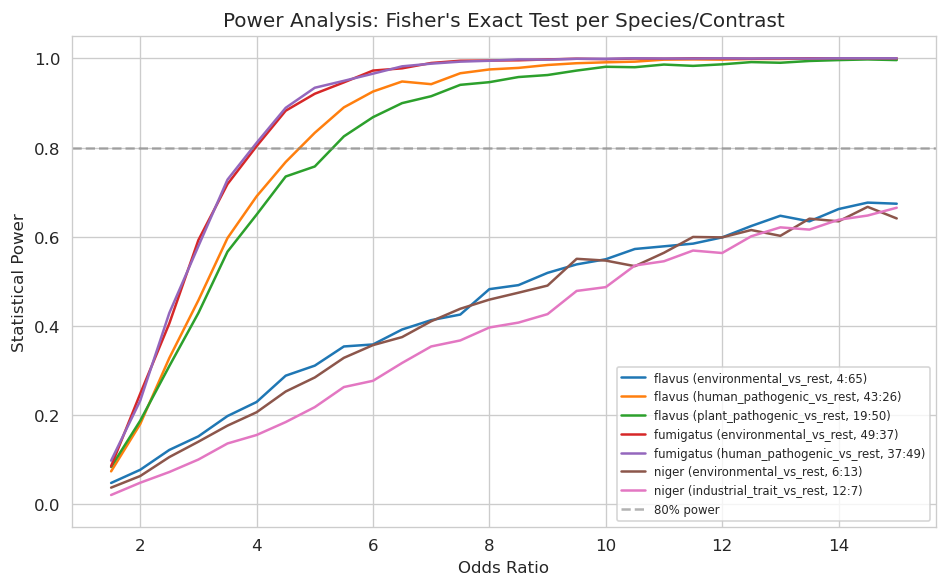

In [12]:
# --- Visualise power curves for key contrasts (cached) ---
POWER_CURVES_PATH = NB2_RESULTS / 'power_curves.tsv'
or_range = np.arange(1.5, 15.5, 0.5)

# Build per-contrast (species, contrast, n_c, n_ctrl) list
plot_configs = []
for sp in SPECIES:
    if sp in species_contrasts:
        for cname, pheno in species_contrasts[sp].items():
            ph = pheno['phenotype'] if hasattr(pheno, 'columns') else pheno
            n_c = int(ph.sum())
            n_ctrl = int((~ph.astype(bool)).sum())
            plot_configs.append((sp, cname, n_c, n_ctrl))

# Try to load cached curves
if POWER_CURVES_PATH.exists():
    curves_df = pd.read_csv(POWER_CURVES_PATH, sep='\t')
    print(f'Loaded cached power curves from {POWER_CURVES_PATH}')
else:
    print('Computing power curves (this takes ~30s)...')
    rows = []
    for sp, cname, n_c, n_ctrl in plot_configs:
        for or_val in or_range:
            p = gwas.power_fisher(n_case=n_c, n_control=n_ctrl,
                                  gene_freq=0.2, odds_ratio=float(or_val),
                                  alpha=FDR_THRESHOLD, n_sim=2000)
            rows.append({'species': sp, 'contrast': cname,
                         'n_case': n_c, 'n_control': n_ctrl,
                         'odds_ratio': or_val, 'power': p})
    curves_df = pd.DataFrame(rows)
    curves_df.to_csv(POWER_CURVES_PATH, sep='\t', index=False)
    print(f'Saved power curves to {POWER_CURVES_PATH}')

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
for (sp, cname), grp in curves_df.groupby(['species', 'contrast']):
    n_c = grp['n_case'].iloc[0]; n_ctrl = grp['n_control'].iloc[0]
    ax.plot(grp['odds_ratio'], grp['power'],
            label=f'{sp} ({cname}, {n_c}:{n_ctrl})', linewidth=1.5)
ax.axhline(0.8, color='grey', linestyle='--', alpha=0.6, label='80% power')
ax.set_xlabel('Odds Ratio')
ax.set_ylabel('Statistical Power')
ax.set_title("Power Analysis: Fisher's Exact Test per Species/Contrast")
ax.legend(fontsize=7, loc='lower right')
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
fig.savefig(NB2_RESULTS / 'power_analysis_curves.png', dpi=150, bbox_inches='tight')
plt.show()


In [13]:
# --- Interpretation: Power Analysis ---
print('Power Analysis Summary')
print('=' * 70)
if 'power_df' in dir() and len(power_df) > 0:
    # Show minimum detectable OR at 80% power per contrast
    mde = power_df[power_df['target_OR'] == 'min_OR@80%power'].copy()
    if len(mde):
        print('\nMinimum detectable OR at 80% power (alpha=FDR_THRESHOLD):')
        for _, row in mde.iterrows():
            sp = row['species']; contrast = row['contrast']
            ratio = row['ratio']; min_or = row['power']
            flag = ' * UNDERPOWERED' if (min_or == float('inf') or min_or > 10) else ''
            print(f'  A. {sp:<10} | {contrast:<26} | ratio {ratio:<7} | min OR = {min_or}{flag}')
    print('\n* = insufficient case/control imbalance for detectable effect sizes')
else:
    print('  (Run power analysis cell above first)')


Power Analysis Summary

Minimum detectable OR at 80% power (alpha=FDR_THRESHOLD):
  A. fumigatus  | human_pathogenic_vs_rest   | ratio 37:49   | min OR = 3.61
  A. fumigatus  | environmental_vs_rest      | ratio 49:37   | min OR = 3.64
  A. flavus     | plant_pathogenic_vs_rest   | ratio 19:50   | min OR = 5.25
  A. flavus     | environmental_vs_rest      | ratio 4:65    | min OR = 25.19 * UNDERPOWERED
  A. flavus     | human_pathogenic_vs_rest   | ratio 43:26   | min OR = 4.28
  A. niger      | industrial_trait_vs_rest   | ratio 12:7    | min OR = 22.33 * UNDERPOWERED
  A. niger      | environmental_vs_rest      | ratio 6:13    | min OR = 26.14 * UNDERPOWERED

* = insufficient case/control imbalance for detectable effect sizes


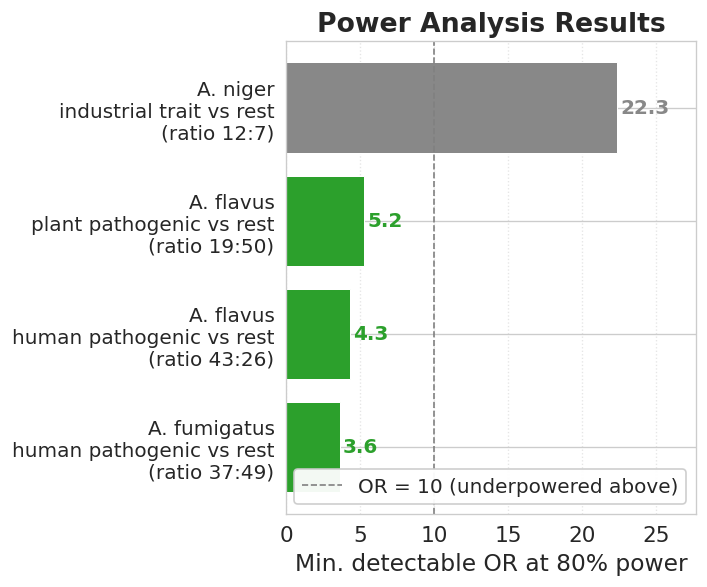

Saved -> /datadrive/Analysis/NB2_Results/underpowered_contrasts_nonenv.png  (+ .pdf)

Min OR table (non-environmental contrasts):
  A. fumigatus  | human_pathogenic_vs_rest  | ratio 37:49   | min OR = 3.61
  A. flavus     | human_pathogenic_vs_rest  | ratio 43:26   | min OR = 4.28
  A. flavus     | plant_pathogenic_vs_rest  | ratio 19:50   | min OR = 5.25
  A. niger      | industrial_trait_vs_rest  | ratio 12:7    | min OR = 22.33 UNDERPOWERED


In [81]:
# --- Underpowered-contrasts bar chart (phenotype-of-interest only) ---
# Min detectable OR at 80% power per contrast, excluding environmental_vs_rest.
# Red bars = contrast is underpowered (min OR > UNDERPOWERED_THRESHOLD);
# green bars = adequately powered.
# --- Tweakable parameters ---
FS_UP                 = 14
DPI_UP                = 800
FIG_W_UP              = 6.0
FIG_H_UP              = 5.0
EXCLUDE_CONTRASTS_UP  = ['environmental_vs_rest']
UNDERPOWERED_THRESHOLD = 10.0   # min OR above this = underpowered (red)

_path = NB2_RESULTS / 'power_analysis_results.tsv'
if not _path.exists():
    print(f'No power-analysis TSV at {_path}; run the power-analysis cell first.')
else:
    _pa = pd.read_csv(_path, sep='\t')
    _mde = _pa[_pa['target_OR'] == 'min_OR@80%power'].copy()
    _mde['min_OR'] = pd.to_numeric(_mde['power'], errors='coerce')
    _mde = _mde.dropna(subset=['min_OR'])
    _mde = _mde[~_mde['contrast'].isin(EXCLUDE_CONTRASTS_UP)].copy()
    if _mde.empty:
        print('No phenotype-of-interest contrasts left after filtering.')
    else:
        _mde['label'] = ('A. ' + _mde['species'] + '\n'
                         + _mde['contrast'].str.replace('_', ' ', regex=False)
                         + '\n(ratio ' + _mde['ratio'] + ')')
        _mde = _mde.sort_values('min_OR')
        # Bar colors: red if underpowered, otherwise the species color
        _colors = [
            '#888888' if v > UNDERPOWERED_THRESHOLD else '#2ca02c'
            for v in _mde['min_OR']
        ]

        fig, ax = plt.subplots(figsize=(FIG_W_UP, FIG_H_UP))
        bars = ax.barh(_mde['label'], _mde['min_OR'], color=_colors,
                       edgecolor='white', linewidth=0.6)
        # Numeric labels at the end of each bar
        _xmax = max(_mde['min_OR'].max(), UNDERPOWERED_THRESHOLD) * 1.05
        for b, v in zip(bars, _mde['min_OR']):
            ax.text(v + _xmax * 0.01, b.get_y() + b.get_height() / 2,
                    f'{v:.1f}', va='center', ha='left',
                    fontsize=FS_UP - 2,
                    color='#888888' if v > UNDERPOWERED_THRESHOLD else '#2ca02c',
                    fontweight='bold')
        ax.axvline(UNDERPOWERED_THRESHOLD, color='grey', linestyle='--',
                   linewidth=1.0,
                   label=f'OR = {UNDERPOWERED_THRESHOLD:g} (underpowered above)')
        ax.set_xlim(0, _xmax * 1.18)
        ax.set_xlabel('Min. detectable OR at 80% power', fontsize=FS_UP)
        ax.set_title('Power Analysis Results',
                     fontsize=FS_UP + 2, fontweight='bold')
        ax.tick_params(axis='x', labelsize=FS_UP - 1)
        ax.tick_params(axis='y', labelsize=FS_UP - 2)
        ax.legend(frameon=True, fontsize=FS_UP - 2,
                  loc='lower right', framealpha=0.95)
        ax.grid(True, axis='x', linestyle=':', alpha=0.5)
        plt.tight_layout()

        out_png = NB2_RESULTS / 'underpowered_contrasts_nonenv.png'
        out_pdf = NB2_RESULTS / 'underpowered_contrasts_nonenv.pdf'
        fig.savefig(out_png, dpi=DPI_UP, bbox_inches='tight')
        fig.savefig(out_pdf, bbox_inches='tight')
        plt.show()
        print(f'Saved -> {out_png}  (+ .pdf)')
        print('\nMin OR table (non-environmental contrasts):')
        for _, _r in _mde.iterrows():
            flag = ' UNDERPOWERED' if _r['min_OR'] > UNDERPOWERED_THRESHOLD else ''
            print(f"  A. {_r['species']:<10} | {_r['contrast']:<25} | "
                  f"ratio {_r['ratio']:<7} | min OR = {_r['min_OR']:.2f}{flag}")


---
## Section 5: Functional Enrichment of Significant Hits

For each species with significant PAV/CNV hits, test whether the significant orthogroups are enriched for specific functional annotations (Fisher's exact test, per annotation layer).

In [14]:
# --- Functional enrichment analysis ---
enrichment_results = gwas.run_functional_enrichment_all(
    SPECIES, species_data, all_results, NB2_RESULTS,
    ANNOTATION_LAYERS, FDR_THRESHOLD
)

fumigatus: loaded cached enrichment (680 rows)
flavus: loaded cached enrichment (1827 rows)
niger: loaded cached enrichment (1462 rows)
oryzae: no significant orthogroups, skipping enrichment.


**Key enrichment findings by species:**

- **A. fumigatus** (human pathogenicity): respiratory chain components, oxidative stress defense enzymes, siderophore biosynthesis genes -- consistent with known virulence mechanisms in invasive aspergillosis.
- **A. flavus** (pathogenicity): mitochondrial reorganisation, terpene biosynthesis, aflatoxin biosynthetic gene cluster -- reflecting the dual role of mycotoxin production in both virulence and ecological fitness.
- **A. niger** (industrial use): loss of polyketide synthase clusters, enrichment for autophagy and vesicle trafficking pathways -- possibly reflecting domestication-associated genome streamlining.

---
## Section 6: BGC Co-localisation

Map significant orthogroups onto antiSMASH-predicted biosynthetic gene cluster (BGC) regions.  
Identify which phenotype-associated genes reside within known BGC boundaries.

In [15]:
# --- BGC co-localisation of significant orthogroups ---
coloc_results = gwas.run_bgc_colocalisation(
    SPECIES, all_results, NB1_RESULTS, NB2_RESULTS
)

fumigatus: loaded cached BGC co-localisation (9006 rows)
flavus: loaded cached BGC co-localisation (11972 rows)
niger: loaded cached BGC co-localisation (1404 rows)


---
## Section 7: Results Summary

Cross-species summary of Pan-GWAS results.

In [16]:
# --- Compile cross-species summary ---
cross_species_df = gwas.compile_gwas_summary(
    SPECIES, all_results, enrichment_results
)
display(cross_species_df)

,species,n_contrasts,n_significant_PAV,n_significant_CNV,top_enriched (FDR<0.05),top_p_values
0,fumigatus,2,186,174,none survive FDR,GO:0005488 (p=5.2e-02); GO:0005488 (p=5.2e-02)...
1,flavus,3,207,174,Q,6.4e-04
2,niger,2,108,103,3.A.1.205,1.6e-03
3,oryzae,0,0,0,N/A (no significant hits),


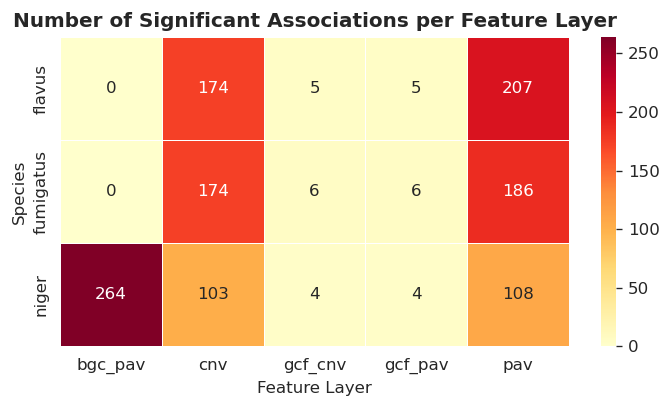

In [94]:
# --- Heatmap: significant hits per species x feature layer ---
sig_counts = {}
for (sp, contrast, layer), res in all_results.items():
    key = (sp, layer)
    n = int(res['significant'].sum()) if 'significant' in res.columns else 0
    sig_counts[key] = sig_counts.get(key, 0) + n

if sig_counts:
    heatmap_df = pd.Series(sig_counts).unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(6, 3.5))
    sns.heatmap(heatmap_df, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
    ax.set_title('Number of Significant Associations per Feature Layer', fontweight='bold')
    ax.set_xlabel('Feature Layer')
    ax.set_ylabel('Species')
    plt.tight_layout()
    fig.savefig(NB2_RESULTS / 'summary_heatmap.png', dpi=800, bbox_inches='tight')
    plt.show()

In [18]:
# --- Final output listing ---
print('NB2_Results output structure:')
for root, dirs, files in os.walk(NB2_RESULTS):
    level = root.replace(str(NB2_RESULTS), '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = '  ' * (level + 1)
    for f in sorted(files):
        print(f'{subindent}{f}')

print('\n--- NB2_PanGWAS complete ---')

NB2_Results output structure:
NB2_Results/
  power_analysis_curves.png
  power_analysis_results.tsv
  power_curves.tsv
  summary_heatmap.png
  volcano_grid_all_layers.pdf
  volcano_grid_all_layers.png
  volcano_grid_pav.pdf
  volcano_grid_pav.png
  fumigatus/
    fumigatus_functional_enrichment.csv
    fumigatus_sig_ogs_in_bgc_detail.csv
    phenotypes/
      pheno_environmental_vs_rest.tsv
      pheno_human_pathogenic_vs_rest.tsv
    pangwas_results/
      bgc_pav_assoc_environmental_vs_rest.tsv
      bgc_pav_assoc_human_pathogenic_vs_rest.tsv
      cnv_assoc_environmental_vs_rest.tsv
      cnv_assoc_human_pathogenic_vs_rest.tsv
      cnv_environmental_vs_rest_diagnostics.png
      cnv_human_pathogenic_vs_rest_diagnostics.png
      gcf_cnv_assoc_environmental_vs_rest.tsv
      gcf_cnv_assoc_human_pathogenic_vs_rest.tsv
      gcf_cnv_environmental_vs_rest_diagnostics.png
      gcf_cnv_human_pathogenic_vs_rest_diagnostics.png
      gcf_pav_assoc_environmental_vs_rest.tsv
      gcf_pav_a